# Решение

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)


### Что делаю?

Сравниваю разные семейства моделей на одной `StratifiedKFold` из пяти фолдов, получаю OOF-предсказания и собираю rank blend.

Feature set берется из `.local/feature_engineering/selected_features.json`, полученный на этапе Feature Engineering.



In [31]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC


SEED = 143

N_TRIALS_LOGREG = 80
N_TRIALS_RF = 80
N_TRIALS_LGBM = 220
N_TRIALS_SVC = 300
N_TRIALS_KNN = 30

SVC_TUNE_SIZE = 60_000
SVC_TRAIN_SIZE = 60_000
KNN_TUNE_SIZE = 15_000
KNN_TRAIN_SIZE = 10_000
PREDICT_CHUNK_SIZE = 20_000

OUTPUTS_DIR = Path("outputs")
LOCAL_DIR = Path(".local")

OUTPUTS_DIR.mkdir(exist_ok=True)
LOCAL_DIR.mkdir(exist_ok=True)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.CRITICAL)


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


## Данные и валидация

Все обучаемые преобразования находятся внутри пайплайнов. Один и тот же `cv` используется для подбора параметров, OOF-предсказаний и сравнения моделей.


In [3]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

selected_features_path = LOCAL_DIR / "feature_engineering" / "selected_features.json"

if selected_features_path.exists():
    with open(selected_features_path) as file:
        selected_columns = json.load(file)
else:
    selected_columns = [
        column for column in train_df.columns
        if column not in [
            'id', 'target', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
            'ps_ind_13_bin', 'ps_ind_14', 'ps_car_10_cat'
        ]
    ]

X_train = train_df[selected_columns].copy()
y_train = train_df['target']
X_test = test_df[selected_columns].copy()

cat_columns = [column for column in X_train.columns if column.endswith('_cat')]
num_columns = [column for column in X_train.columns if column not in cat_columns]


In [32]:
def normalized_gini(y_true, y_pred_proba):  # в cross_val_score по умолчанию его нет, но он легко выражается из roc_auc
    return 2 * roc_auc_score(y_true, y_pred_proba) - 1


gini_scorer = make_scorer(normalized_gini, response_method="predict_proba")
gini_decision_scorer = make_scorer(normalized_gini, response_method="decision_function")

submission_names = {
    "gaussian_nb": "gnb_submission.csv",
    "logistic_regression": "logreg_submission.csv",
    "random_forest": "rf_submission.csv",
    "lightgbm": "lgbm_submission.csv",
    "svc_rbf": "svc_rbf_submission.csv",
    "knn": "knn_submission.csv",
}


def get_model_dir(model_name):
    model_dir = LOCAL_DIR / model_name
    model_dir.mkdir(exist_ok=True)
    return model_dir


def evaluate_trial(model, X, y, score_history, scoring=gini_scorer, n_jobs=-1):
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs)
    score_history.append({
        'val_gini': scores[0],
        'other_folds_gini': scores[1:].mean(),
        'mean_gini': scores.mean(),
    })
    return scores.mean()


def run_optuna(objective, model_name, n_trials, timeout=3 * 60 * 60):
    study = optuna.create_study(
        study_name=model_name,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=10),
    )
    study.optimize(
        objective, n_trials=n_trials, timeout=timeout,
        gc_after_trial=False, show_progress_bar=False
    )

    model_dir = get_model_dir(model_name)
    study.trials_dataframe().to_csv(model_dir / "optuna_trials.csv", index=False)

    with open(model_dir / "best_params.json", "w") as file:
        json.dump(study.best_params, file, indent=4)

    return study


def plot_score_history(score_history, model_name, title):
    model_dir = get_model_dir(model_name)

    history = pd.DataFrame(score_history)
    history.index = np.arange(1, len(history) + 1)
    history.index.name = "iteration"
    history["gap"] = history["val_gini"] - history["other_folds_gini"]
    history.to_csv(model_dir / "score_history.csv")

    scores = history[["val_gini", "other_folds_gini"]].rename(columns={
        "val_gini": "val fold",
        "other_folds_gini": "mean other folds",
    })
    smoothed_scores = scores.rolling(window=7, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    scores.plot(ax=ax, marker="o", alpha=0.2, legend=False)
    smoothed_scores.plot(ax=ax, linewidth=2.5)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Normalized Gini")
    ax.set_title(title)
    fig.savefig(model_dir / "learning_curve.png", bbox_inches="tight")
    plt.show()

    return history


def get_oof_predictions(model, X, y, n_jobs=1):
    predictions = cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=n_jobs)[:, 1]
    fold_scores = [
        normalized_gini(y.iloc[valid_index], predictions[valid_index])
        for _, valid_index in cv.split(X, y)
    ]
    return predictions, np.array(fold_scores)


def stratified_sample(X, y, n_samples, random_state):
    if n_samples >= len(X):
        return X.copy(), y.copy()

    sample_index, _ = train_test_split(
        np.arange(len(X)), train_size=n_samples, stratify=y, random_state=random_state
    )
    return X.iloc[sample_index], y.iloc[sample_index]


def predict_scores(model, X, response_method, chunk_size=PREDICT_CHUNK_SIZE):
    predictions = []

    for start in range(0, len(X), chunk_size):
        X_chunk = X.iloc[start:start + chunk_size]
        if response_method == "predict_proba":
            chunk_predictions = model.predict_proba(X_chunk)[:, 1]
        else:
            chunk_predictions = model.decision_function(X_chunk)
        predictions.append(chunk_predictions)

    return np.concatenate(predictions)


def get_subsampled_oof_predictions(model, X, y, train_size, response_method):
    predictions = np.zeros(len(X))
    fold_scores = []

    for fold, (train_index, valid_index) in enumerate(cv.split(X, y), start=1):
        X_fit, y_fit = stratified_sample(X.iloc[train_index], y.iloc[train_index], train_size, SEED + fold)
        fold_model = clone(model)
        fold_model.fit(X_fit, y_fit)

        fold_predictions = predict_scores(fold_model, X.iloc[valid_index], response_method)
        predictions[valid_index] = fold_predictions
        fold_scores.append(normalized_gini(y.iloc[valid_index], fold_predictions))

    return predictions, np.array(fold_scores)


def fit_subsampled_model(model, X, y, train_size):
    X_fit, y_fit = stratified_sample(X, y, train_size, SEED)
    fitted_model = clone(model)
    fitted_model.fit(X_fit, y_fit)
    return fitted_model


def rank_predictions(predictions):
    return pd.Series(predictions).rank(pct=True).to_numpy()


def save_model_outputs(model_name, oof_predictions, test_predictions):
    model_dir = get_model_dir(model_name)

    pd.DataFrame({
        "id": train_df["id"],
        "target": y_train,
        "prediction": oof_predictions,
    }).to_csv(model_dir / "oof_predictions.csv", index=False)

    submission = pd.DataFrame({"id": test_df["id"], "target": test_predictions})
    submission.to_csv(OUTPUTS_DIR / submission_names[model_name], index=False)
    return submission


### GaussianNB

Быстрый baseline (быстро работает и не требует настройки). Категориальные признаки кодируются через `OneHotEncoder` внутри CV-пайплайна.


In [5]:
gaussian_nb_preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), make_column_selector(pattern='_cat$'))],
    remainder='passthrough'
)

gaussian_nb_model = make_pipeline(gaussian_nb_preprocessor, GaussianNB())
gaussian_nb_oof, gaussian_nb_fold_scores = get_oof_predictions(
    gaussian_nb_model, X_train, y_train, n_jobs=-1
)

pd.DataFrame({
    'model': ['gaussian_nb'],
    'mean_gini': [gaussian_nb_fold_scores.mean()],
    'std_gini': [gaussian_nb_fold_scores.std()],
})


,model,mean_gini,std_gini
0,gaussian_nb,0.180968,0.009682


In [6]:
gaussian_nb_model.fit(X_train, y_train)
gaussian_nb_test_predictions = gaussian_nb_model.predict_proba(X_test)[:, 1]
gaussian_nb_submission = save_model_outputs("gaussian_nb", gaussian_nb_oof, gaussian_nb_test_predictions)
gaussian_nb_submission.head()


,id,target
0,0,9.697845e-10
1,1,6.981414e-09
2,2,2.188061e-07
3,3,3.835647e-10
4,4,2.158711e-06


**Результат.** GaussianNB дал `OOF Gini = 0.1806`, `Private = 0.18599`, `Public = 0.18858`. Бейслайн...


### Logistic Regression

Линейный baseline с One-Hot Encoding и масштабированием внутри пайплайна. Optuna подбирает силу и тип регуляризации через `C` и `l1_ratio`.


In [7]:
logistic_regression_preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), make_column_selector(pattern='_cat$'))],
    remainder=StandardScaler(),
    sparse_threshold=1.0
)


In [8]:
logistic_regression_score_history = []


def logistic_regression_objective(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 3.0, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0, step=0.1),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }

    model = make_pipeline(
        logistic_regression_preprocessor,
        LogisticRegression(**params, solver="saga", random_state=SEED, max_iter=5_000, tol=5e-4)
    )
    return evaluate_trial(model, X_train, y_train, logistic_regression_score_history, n_jobs=-1)


In [9]:
logistic_regression_study = run_optuna(
    logistic_regression_objective, "logistic_regression", N_TRIALS_LOGREG
)

best_params_logistic_regression = logistic_regression_study.best_params
best_score_logistic_regression = logistic_regression_study.best_value


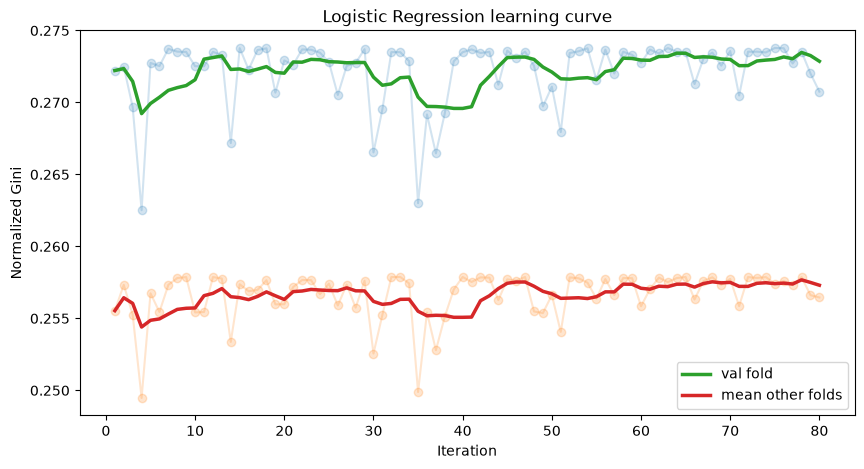

In [33]:
logistic_regression_history = plot_score_history(
    logistic_regression_score_history, "logistic_regression", "Logistic Regression learning curve"
)


In [11]:
logistic_regression_model = make_pipeline(
    logistic_regression_preprocessor,
    LogisticRegression(
        **best_params_logistic_regression, solver="saga",
        random_state=SEED, max_iter=5_000, tol=5e-4
    )
)

logistic_regression_oof, logistic_regression_fold_scores = get_oof_predictions(
    logistic_regression_model, X_train, y_train, n_jobs=-1
)

logistic_regression_model.fit(X_train, y_train)
logistic_regression_test_predictions = logistic_regression_model.predict_proba(X_test)[:, 1]
logistic_regression_submission = save_model_outputs(
    "logistic_regression", logistic_regression_oof, logistic_regression_test_predictions
)
logistic_regression_submission.head()


,id,target
0,0,0.451606
1,1,0.465911
2,2,0.422662
3,3,0.320586
4,4,0.502646


**Результат.** Logistic Regression дала `OOF Gini = 0.2609`, `Private = 0.26737`, `Public = 0.26089`. 

Модель заметно сильнее baseline и полезна в ансамбле как линейная модель с отличающимися ошибками.


### Random Forest

Нелинейная bagging-модель.


In [12]:
random_forest_score_history = []


def random_forest_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 700, step=50),
        "max_depth": trial.suggest_categorical("max_depth", [8, 12, 16, None]),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 150, step=10),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 10, 25]),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", 0.2, 0.35, 0.5]),
        "max_samples": trial.suggest_categorical("max_samples", [0.5, 0.7, 0.9]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced_subsample"]),
    }

    model = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    return evaluate_trial(model, X_train, y_train, random_forest_score_history, n_jobs=1)


In [13]:
random_forest_study = run_optuna(random_forest_objective, "random_forest", N_TRIALS_RF)

best_params_random_forest = random_forest_study.best_params
best_score_random_forest = random_forest_study.best_value


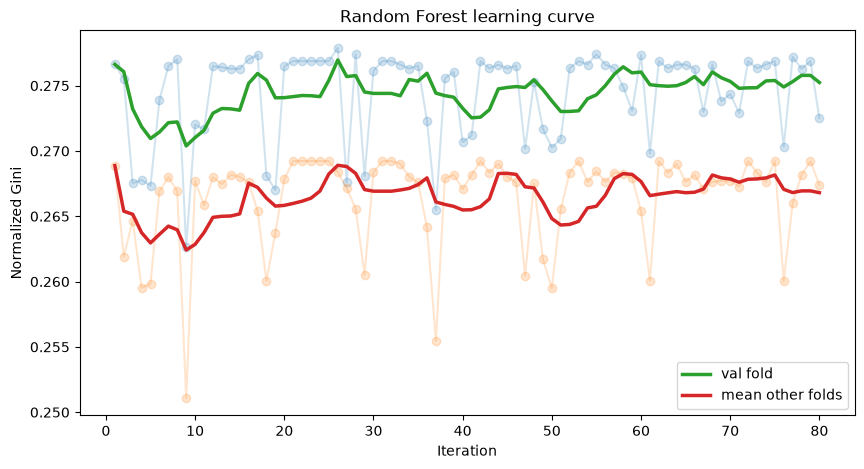

In [34]:
random_forest_history = plot_score_history(
    random_forest_score_history, "random_forest", "Random Forest learning curve"
)


In [15]:
random_forest_model = RandomForestClassifier(
    **best_params_random_forest, random_state=SEED, n_jobs=-1
)

random_forest_oof, random_forest_fold_scores = get_oof_predictions(
    random_forest_model, X_train, y_train, n_jobs=1
)

random_forest_model.fit(X_train, y_train)
random_forest_test_predictions = random_forest_model.predict_proba(X_test)[:, 1]
random_forest_submission = save_model_outputs(
    "random_forest", random_forest_oof, random_forest_test_predictions
)
random_forest_submission.head()


,id,target
0,0,0.025515
1,1,0.023597
2,2,0.030962
3,3,0.014361
4,4,0.038579


**Результат.** Random Forest дал `OOF Gini = 0.2706 ± 0.0064`, `Private = 0.27011`, `Public = 0.26441`.


### LightGBM

Основная бустинговая модель. `_cat`-признаки переводятся в `pandas.Categorical` только в отдельных копиях данных для LightGBM.


In [16]:
X_train_lightgbm = X_train.copy()
X_test_lightgbm = X_test.copy()

for column in cat_columns:
    categories = pd.Index(X_train[column].unique())
    X_train_lightgbm[column] = pd.Categorical(X_train[column], categories=categories)
    X_test_lightgbm[column] = pd.Categorical(X_test[column], categories=categories)


In [17]:
lightgbm_score_history = []


def lightgbm_objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 6, 8, 10]),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 400, 1_400, step=100),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 250, step=10),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0, step=0.05),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.05),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "max_bin": trial.suggest_categorical("max_bin", [63, 127, 255]),
    }

    model = LGBMClassifier(
        **params, subsample_freq=1, verbosity=-1, random_state=SEED, n_jobs=-1
    )
    return evaluate_trial(model, X_train_lightgbm, y_train, lightgbm_score_history, n_jobs=1)


In [18]:
lightgbm_study = run_optuna(lightgbm_objective, "lightgbm", N_TRIALS_LGBM)

best_params_lightgbm = lightgbm_study.best_params
best_score_lightgbm = lightgbm_study.best_value


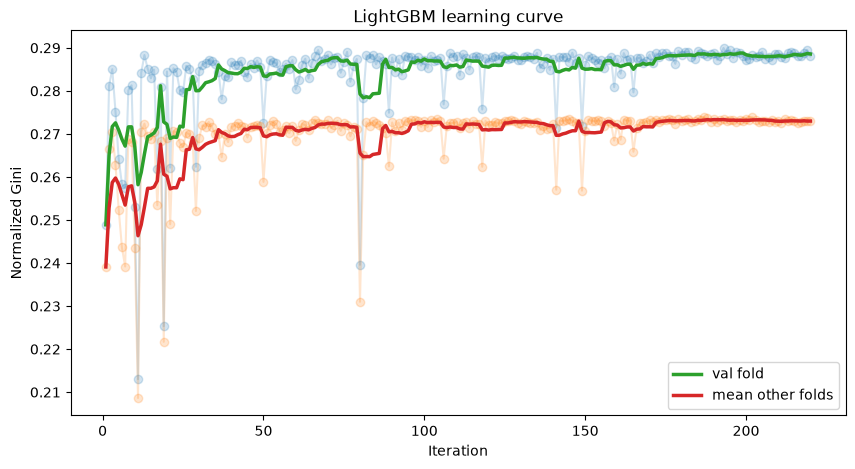

In [35]:
lightgbm_history = plot_score_history(
    lightgbm_score_history, "lightgbm", "LightGBM learning curve"
)


In [20]:
lightgbm_model = LGBMClassifier(
    **best_params_lightgbm, subsample_freq=1, verbosity=-1, random_state=SEED, n_jobs=-1
)

lightgbm_oof, lightgbm_fold_scores = get_oof_predictions(
    lightgbm_model, X_train_lightgbm, y_train, n_jobs=1
)

lightgbm_model.fit(X_train_lightgbm, y_train)
lightgbm_test_predictions = lightgbm_model.predict_proba(X_test_lightgbm)[:, 1]
lightgbm_submission = save_model_outputs("lightgbm", lightgbm_oof, lightgbm_test_predictions)
lightgbm_submission.head()


,id,target
0,0,0.031119
1,1,0.029889
2,2,0.024026
3,3,0.016242
4,4,0.038853


**Результат.** LightGBM стал лучшей одиночной моделью: `OOF Gini = 0.2767 ± 0.0070`, `Private = 0.28256`, `Public = 0.27655`. 


### RBF-SVC

Точный RBF-SVC обучаю на стратифицированной подвыборке внутри каждого фолда. Категории кодируются порядковыми значениями, все признаки масштабируются, затем `SelectKBest` выбирает признаки только по train-части фолда.

Для Gini использую `decision_function`; калибровка вероятностей здесь не нужна.


In [36]:
distance_preprocessor = ColumnTransformer([
    (
        'cat',
        make_pipeline(
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            StandardScaler()
        ),
        cat_columns
    ),
    ('num', StandardScaler(), num_columns)
])

X_train_svc_tune, y_train_svc_tune = stratified_sample(
    X_train, y_train, SVC_TUNE_SIZE, SEED
)


In [37]:
svc_rbf_score_history = []


def svc_rbf_objective(trial):
    k = trial.suggest_categorical("k", [12, 20, 30, 40, "all"])

    model = make_pipeline(
        distance_preprocessor,
        SelectKBest(f_classif, k=k),
        SVC(
            kernel="rbf",
            C=trial.suggest_categorical("C", [0.3, 0.6, 1.0, 2.0, 5.0, 10.0, 20.0]),
            gamma=trial.suggest_categorical("gamma", [0.002, 0.005, 0.01, 0.02, 0.05]),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            cache_size=1_500,
            tol=1e-3,
            max_iter=100_000
        )
    )
    return evaluate_trial(
        model, X_train_svc_tune, y_train_svc_tune,
        svc_rbf_score_history, scoring=gini_decision_scorer, n_jobs=-1
    )


In [38]:
svc_rbf_study = run_optuna(svc_rbf_objective, "svc_rbf", N_TRIALS_SVC)

best_params_svc_rbf = svc_rbf_study.best_params.copy()
best_score_svc_rbf = svc_rbf_study.best_value


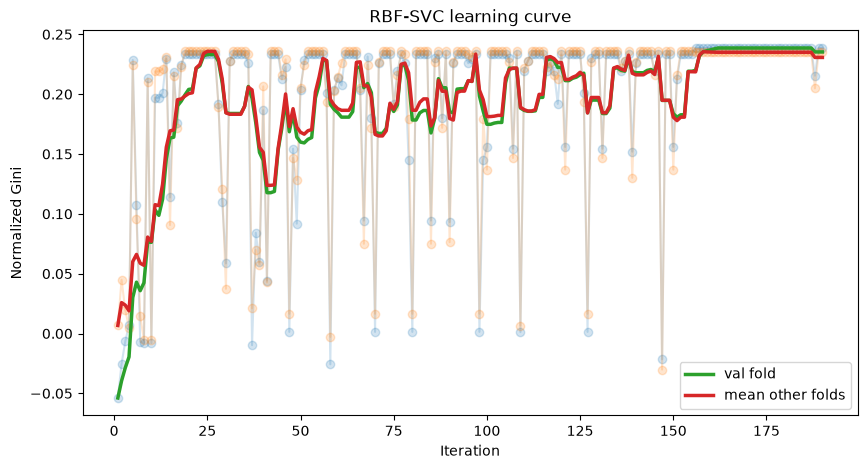

In [39]:
svc_rbf_history = plot_score_history(
    svc_rbf_score_history, "svc_rbf", "RBF-SVC learning curve"
)


In [40]:
svc_rbf_k = best_params_svc_rbf.pop("k")

svc_rbf_model = make_pipeline(
    distance_preprocessor,
    SelectKBest(f_classif, k=svc_rbf_k),
    SVC(
        **best_params_svc_rbf, kernel='rbf',
        cache_size=1_500, tol=1e-3, max_iter=20_000
    )
)

svc_rbf_oof, svc_rbf_fold_scores = get_subsampled_oof_predictions(
    svc_rbf_model, X_train, y_train, SVC_TRAIN_SIZE, response_method="decision_function"
)
svc_rbf_model = fit_subsampled_model(svc_rbf_model, X_train, y_train, SVC_TRAIN_SIZE)
svc_rbf_test_predictions = predict_scores(
    svc_rbf_model, X_test, response_method="decision_function"
)

svc_rbf_submission = save_model_outputs(
    "svc_rbf", svc_rbf_oof, rank_predictions(svc_rbf_test_predictions)
)
svc_rbf_submission.head()


,id,target
0,0,0.800901
1,1,0.457907
2,2,0.439564
3,3,0.432456
4,4,0.550430


**Результат.** RBF-SVC дал отрицательный `OOF Gini = -0.0398`, `Private = -0.09741`, `Public = -0.09060`. Неудачно получилось, возможно, где-то ошибка в коде закралась...


### Визуализация разделяющей поверхности RBF-SVC

Для 2D-графика беру два наиболее важных **числовых** признака по финальному Random Forest.


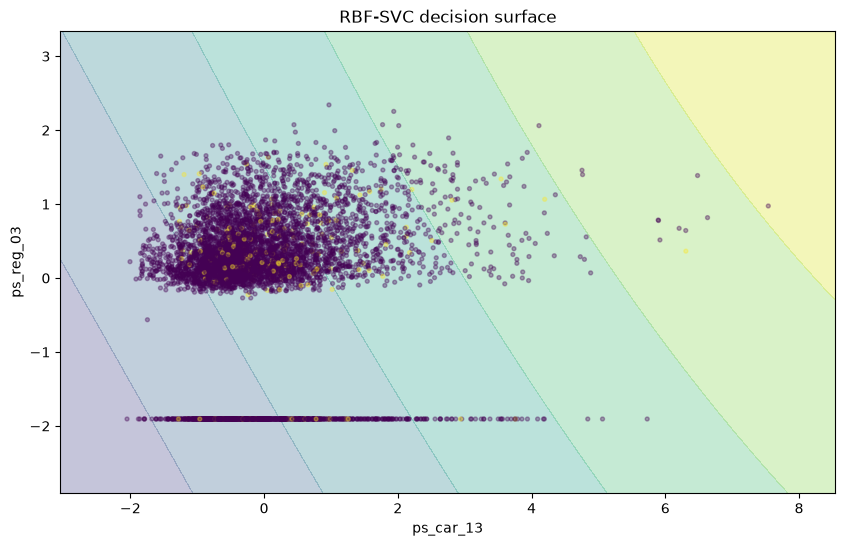

In [41]:
feature_importance = pd.Series(
    random_forest_model.feature_importances_, index=X_train.columns
)
svc_2d_features = feature_importance.loc[num_columns].nlargest(2).index.tolist()

X_svc_2d, _, y_svc_2d, _ = train_test_split(
    X_train[svc_2d_features], y_train,
    train_size=6_000, stratify=y_train, random_state=SEED
)

svc_2d_scaler = StandardScaler()
X_svc_2d_scaled = svc_2d_scaler.fit_transform(X_svc_2d)

svc_2d_model = SVC(
    kernel='rbf',
    C=best_params_svc_rbf["C"],
    gamma=best_params_svc_rbf["gamma"],
    class_weight=best_params_svc_rbf["class_weight"],
    cache_size=1_000
)
svc_2d_model.fit(X_svc_2d_scaled, y_svc_2d)

fig, ax = plt.subplots(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(
    svc_2d_model, X_svc_2d_scaled,
    response_method='decision_function', plot_method='contourf',
    grid_resolution=150, alpha=0.3, ax=ax
)
ax.scatter(X_svc_2d_scaled[:, 0], X_svc_2d_scaled[:, 1], c=y_svc_2d, s=8, alpha=0.35)

ax.set_xlabel(svc_2d_features[0])
ax.set_ylabel(svc_2d_features[1])
ax.set_title("RBF-SVC decision surface")
fig.savefig(get_model_dir("svc_rbf") / "decision_surface.png", bbox_inches="tight")
plt.show()


**Вывод по визуализации.** На двух важных числовых признаках классы почти полностью пересекаются. Поверхность показывает плавное изменение decision score, но четкой разделяющей области нет; горизонтальная полоса соответствует массовому значению пропуска после масштабирования.

Ошибки в коде, вероятно, все же нет...


### KNN

KNN использует ту же честную предобработку и отбор признаков внутри каждого фолда. 

_Для финального OOF и test ограничиваю число эталонных объектов: точный поиск соседей на полном train слишком тяжелый._


In [42]:
X_train_knn_tune, y_train_knn_tune = stratified_sample(
    X_train, y_train, KNN_TUNE_SIZE, SEED
)

knn_score_history = []


def knn_objective(trial):
    params = {
        "n_neighbors": trial.suggest_categorical("n_neighbors", [50, 100, 150, 250, 400]),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_categorical("p", [1, 2]),
        "leaf_size": trial.suggest_categorical("leaf_size", [30, 60, 100]),
        "algorithm": trial.suggest_categorical("algorithm", ["brute", "ball_tree"]),
        "k": trial.suggest_categorical("k", [12, 20, 30]),
    }

    model = make_pipeline(
        distance_preprocessor,
        SelectKBest(f_classif, k=params.pop("k")),
        KNeighborsClassifier(**params, n_jobs=-1)
    )
    return evaluate_trial(model, X_train_knn_tune, y_train_knn_tune, knn_score_history, n_jobs=1)


In [43]:
knn_study = run_optuna(knn_objective, "knn", N_TRIALS_KNN)

best_params_knn = knn_study.best_params
best_score_knn = knn_study.best_value


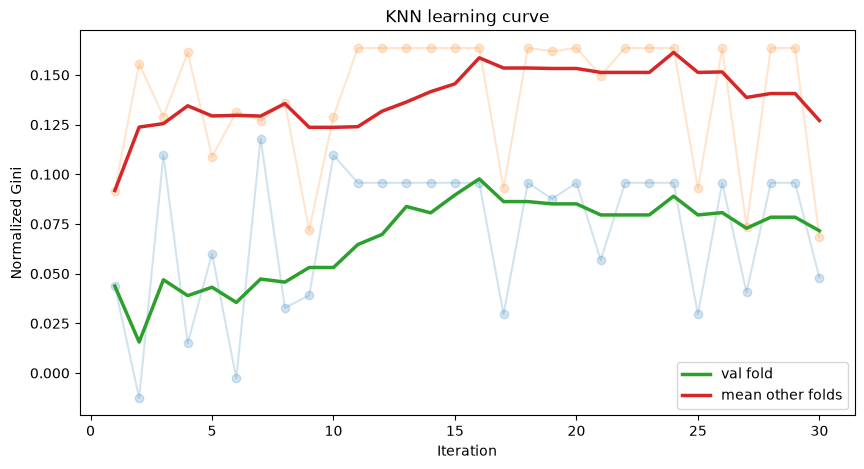

In [44]:
knn_history = plot_score_history(knn_score_history, "knn", "KNN learning curve")


In [45]:
knn_k = best_params_knn.pop("k")

knn_model = make_pipeline(
    distance_preprocessor,
    SelectKBest(f_classif, k=knn_k),
    KNeighborsClassifier(**best_params_knn, n_jobs=-1)
)
best_params_knn["k"] = knn_k

knn_oof, knn_fold_scores = get_subsampled_oof_predictions(
    knn_model, X_train, y_train, KNN_TRAIN_SIZE, response_method="predict_proba"
)
knn_model = fit_subsampled_model(knn_model, X_train, y_train, KNN_TRAIN_SIZE)
knn_test_predictions = predict_scores(knn_model, X_test, response_method="predict_proba")

knn_submission = save_model_outputs("knn", knn_oof, knn_test_predictions)
knn_submission.head()


,id,target
0,0,0.0175
1,1,0.0200
2,2,0.0350
3,3,0.0075
4,4,0.0275


**Результат.** KNN дал `OOF Gini = 0.1771 ± 0.0205`, `Private = 0.19859`, `Public = 0.19171`. Качество слабое, а разброс между фолдами высокий, тоже не оч.


## Сравнение и блендинг

Сравниваю модели по OOF-предсказаниям. Корреляцию считаю по рангам: для Gini важен порядок объектов, а не масштаб вероятностей.


In [46]:
model_scores = pd.DataFrame([
    {
        "model": "gaussian_nb",
        "oof_gini": normalized_gini(y_train, gaussian_nb_oof),
        "mean_fold_gini": gaussian_nb_fold_scores.mean(),
        "std_fold_gini": gaussian_nb_fold_scores.std(),
    },
    {
        "model": "logistic_regression",
        "oof_gini": normalized_gini(y_train, logistic_regression_oof),
        "mean_fold_gini": logistic_regression_fold_scores.mean(),
        "std_fold_gini": logistic_regression_fold_scores.std(),
    },
    {
        "model": "random_forest",
        "oof_gini": normalized_gini(y_train, random_forest_oof),
        "mean_fold_gini": random_forest_fold_scores.mean(),
        "std_fold_gini": random_forest_fold_scores.std(),
    },
    {
        "model": "lightgbm",
        "oof_gini": normalized_gini(y_train, lightgbm_oof),
        "mean_fold_gini": lightgbm_fold_scores.mean(),
        "std_fold_gini": lightgbm_fold_scores.std(),
    },
    {
        "model": "svc_rbf",
        "oof_gini": normalized_gini(y_train, svc_rbf_oof),
        "mean_fold_gini": svc_rbf_fold_scores.mean(),
        "std_fold_gini": svc_rbf_fold_scores.std(),
    },
    {
        "model": "knn",
        "oof_gini": normalized_gini(y_train, knn_oof),
        "mean_fold_gini": knn_fold_scores.mean(),
        "std_fold_gini": knn_fold_scores.std(),
    },
]).sort_values("oof_gini", ascending=False).reset_index(drop=True)

blending_dir = get_model_dir("blending")
model_scores.to_csv(blending_dir / "model_scores.csv", index=False)
model_scores


,model,oof_gini,mean_fold_gini,std_fold_gini
0,lightgbm,0.276733,0.276800,0.006988
1,random_forest,0.270613,0.270753,0.006404
2,logistic_regression,0.260938,0.261005,0.010110
3,gaussian_nb,0.180574,0.180968,0.009682
4,knn,0.177068,0.177331,0.020478
5,svc_rbf,-0.039767,-0.052269,0.031092


**Сравнение.** Три сильные модели -- LightGBM, Random Forest и Logistic Regression. На Kaggle лучшей одиночной моделью тоже стал LightGBM. GaussianNB и KNN заметно слабее, а RBF-SVC получил отрицательный Gini.


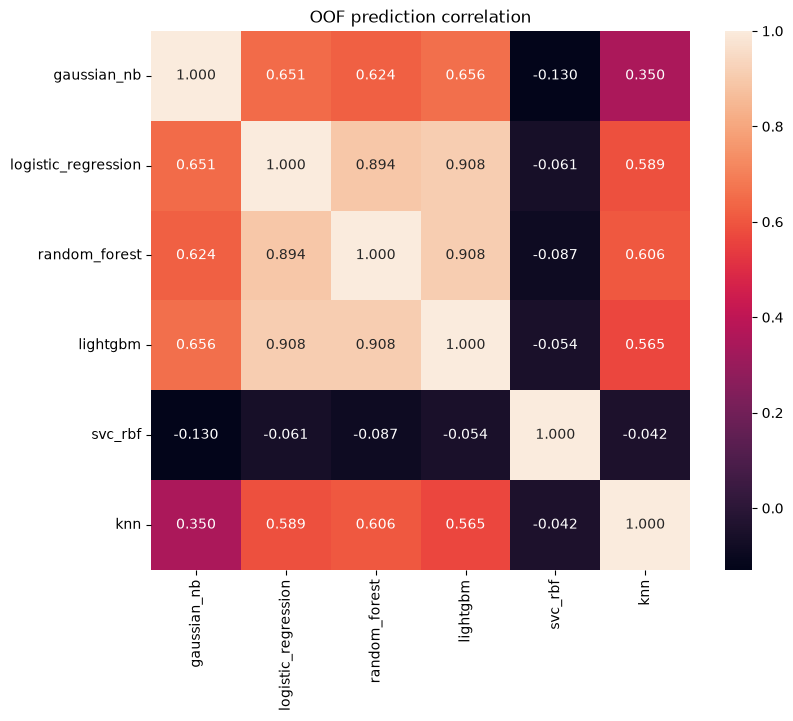

,gaussian_nb,logistic_regression,random_forest,lightgbm,svc_rbf,knn
gaussian_nb,1.000000,0.651327,0.624102,0.656131,-0.129525,0.350025
logistic_regression,0.651327,1.000000,0.893694,0.907910,-0.061052,0.588940
random_forest,0.624102,0.893694,1.000000,0.907782,-0.087410,0.605940
lightgbm,0.656131,0.907910,0.907782,1.000000,-0.054071,0.565095
svc_rbf,-0.129525,-0.061052,-0.087410,-0.054071,1.000000,-0.041679
knn,0.350025,0.588940,0.605940,0.565095,-0.041679,1.000000


In [47]:
oof_predictions = pd.DataFrame({
    "gaussian_nb": gaussian_nb_oof,
    "logistic_regression": logistic_regression_oof,
    "random_forest": random_forest_oof,
    "lightgbm": lightgbm_oof,
    "svc_rbf": svc_rbf_oof,
    "knn": knn_oof,
})

test_predictions = pd.DataFrame({
    "id": test_df["id"],
    "gaussian_nb": gaussian_nb_test_predictions,
    "logistic_regression": logistic_regression_test_predictions,
    "random_forest": random_forest_test_predictions,
    "lightgbm": lightgbm_test_predictions,
    "svc_rbf": svc_rbf_test_predictions,
    "knn": knn_test_predictions,
})

oof_predictions.assign(target=y_train.to_numpy()).to_csv(
    blending_dir / "oof_predictions.csv", index=False
)
test_predictions.to_csv(blending_dir / "test_predictions.csv", index=False)

prediction_correlation = oof_predictions.corr(method="spearman")
prediction_correlation.to_csv(blending_dir / "prediction_correlation.csv")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(prediction_correlation, annot=True, fmt=".3f", square=True, ax=ax)
ax.set_title("OOF prediction correlation")
fig.savefig(blending_dir / "prediction_correlation.png", bbox_inches="tight")
plt.show()

prediction_correlation


**Корреляции.** Предсказания трех сильных моделей коррелируют высоко, но не полностью: Spearman-корреляция находится примерно в диапазоне `0.89–0.91`. Этого достаточно, чтобы проверить блендинг. 

Более маленькие корреляции -- с плохими по скору моделями, не вижу смысла их пробовать в блендинге вообще.


## Блендинг

В финальный ансамбль включаю только три сильные модели:

- Logistic Regression;
- Random Forest;
- LightGBM.

GaussianNB, KNN и RBF-SVC не использую: низкая корреляция их предсказаний не компенсирует слабый собственный Gini.

Проверяю три стратегии rank blending:

1. одинаковые веса;
2. веса пропорционально OOF Gini моделей;
3. веса, подобранные Optuna.

In [50]:
blend_models = ["logistic_regression", "random_forest", "lightgbm"]


def rank_oof_predictions(predictions):
    ranked_predictions = predictions.copy()

    for _, valid_index in cv.split(X_train, y_train):
        ranked_predictions.iloc[valid_index] = predictions.iloc[valid_index].rank(pct=True).to_numpy()

    return ranked_predictions


def make_blend(predictions, weights):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    return predictions.to_numpy() @ weights


def get_blend_fold_scores(predictions):
    return np.array([
        normalized_gini(y_train.iloc[valid_index], predictions[valid_index])
        for _, valid_index in cv.split(X_train, y_train)
    ])


def save_blend(blend_name, weights):
    oof_blend = make_blend(ranked_oof_predictions, weights)
    test_blend = make_blend(ranked_test_predictions, weights)
    fold_scores = get_blend_fold_scores(oof_blend)

    submission = pd.DataFrame({"id": test_df["id"], "target": test_blend})
    submission.to_csv(OUTPUTS_DIR / f"{blend_name}_submission.csv", index=False)

    return {
        "model": blend_name,
        "oof_gini": normalized_gini(y_train, oof_blend),
        "mean_fold_gini": fold_scores.mean(),
        "std_fold_gini": fold_scores.std(),
    }


ranked_oof_predictions = rank_oof_predictions(oof_predictions[blend_models])
ranked_test_predictions = test_predictions[blend_models].rank(pct=True)


In [51]:
equal_weights = np.ones(len(blend_models))
equal_weights = equal_weights / equal_weights.sum()

model_gini = model_scores.set_index("model").loc[blend_models, "oof_gini"].to_numpy()
score_weights = model_gini / model_gini.sum()


def blending_objective(trial):
    weights = np.array([trial.suggest_float(model, 0.0, 1.0) for model in blend_models])

    if weights.sum() == 0:
        return -1.0

    predictions = make_blend(ranked_oof_predictions, weights)
    return get_blend_fold_scores(predictions).mean()


blending_study = run_optuna(blending_objective, "blending", n_trials=300)
optuna_weights = np.array([blending_study.best_params[model] for model in blend_models])
optuna_weights = optuna_weights / optuna_weights.sum()


In [52]:
blend_weights = {
    "equal": equal_weights,
    "score_weighted": score_weights,
    "optuna": optuna_weights,
}

blend_weights_df = pd.DataFrame(blend_weights, index=blend_models)
blend_weights_df.index.name = "model"
blend_weights_df


,equal,score_weighted,optuna
model,,,
logistic_regression,0.333333,0.322830,0.001186
random_forest,0.333333,0.334799,0.356715
lightgbm,0.333333,0.342371,0.642100


**Веса.** Optuna практически исключила Logistic Regression (`0.001`), оставив около `0.357` Random Forest и `0.642` LightGBM. 

Это согласуется с качеством одиночных моделей.


In [53]:
blend_results = [
    save_blend(blend_name, weights)
    for blend_name, weights in blend_weights.items()
]

blend_scores = (
    pd.DataFrame(blend_results)
    .sort_values("oof_gini", ascending=False)
    .reset_index(drop=True)
)
blend_scores


,model,oof_gini,mean_fold_gini,std_fold_gini
0,optuna,0.279857,0.279873,0.006623
1,score_weighted,0.277530,0.277547,0.007800
2,equal,0.277376,0.277393,0.007840


**Результат блендинга.** Лучший вариант -- веса Optuna: `OOF Gini = 0.2799 ± 0.0066`, `Private = 0.28314`, `Public = 0.27717`. 

Равный и пропорциональный score бленды тоже улучшили LightGBM, но слабее.


In [54]:
final_scores = pd.concat([
    model_scores.loc[
        model_scores["model"].isin(blend_models),
        ["model", "oof_gini", "mean_fold_gini", "std_fold_gini"]
    ],
    blend_scores,
], ignore_index=True)

final_scores = final_scores.sort_values("oof_gini", ascending=False).reset_index(drop=True)
final_scores


,model,oof_gini,mean_fold_gini,std_fold_gini
0,optuna,0.279857,0.279873,0.006623
1,score_weighted,0.277530,0.277547,0.007800
2,equal,0.277376,0.277393,0.007840
3,lightgbm,0.276733,0.276800,0.006988
4,random_forest,0.270613,0.270753,0.006404
5,logistic_regression,0.260938,0.261005,0.010110


**Итоговое сравнение.** Optuna-бленд улучшил LightGBM примерно на `0.0031` по OOF, на `0.00058` по Private и на `0.00062` по Public. 

Финальный submission -- `outputs/optuna_submission.csv`.


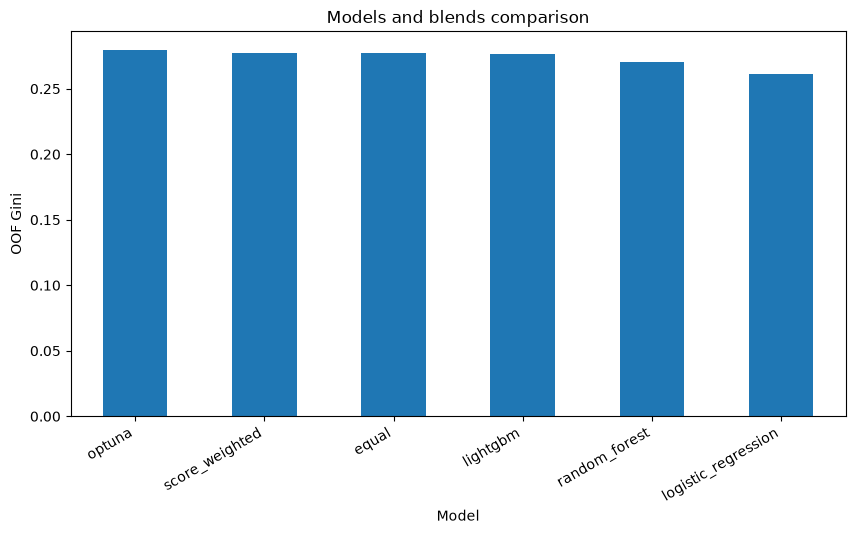

In [55]:
ax = final_scores.plot(
    x="model", y="oof_gini", kind="bar", figsize=(10, 5),
    legend=False, xlabel="Model", ylabel="OOF Gini",
    title="Models and blends comparison"
)

plt.xticks(rotation=30, ha="right")
plt.show()


## Итог

Лучшей одиночной моделью стал LightGBM: `OOF Gini = 0.2767`, `Private = 0.28256`, `Public = 0.27655`.

В финальный rank blend вошли только Logistic Regression, Random Forest и LightGBM. Optuna подобрала веса:

- Logistic Regression -- `0.001`;
- Random Forest -- `0.357`;
- LightGBM -- `0.642`.

Финальный результат:

- `OOF Gini = 0.2799 ± 0.0066`;
- `Private Gini = 0.28314`;
- `Public Gini = 0.27717`;
- гипотетическое место по Private -- `2665 / 5156` (`топ-51.7%`).

GaussianNB, KNN и RBF-SVC не использую в финальном ансамбле: низкая корреляция не компенсирует слабое собственное качество.
